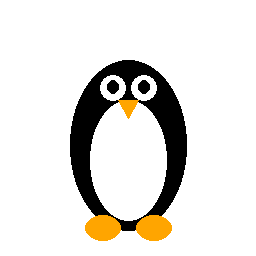

In [ ]:
from PIL import Image
from pathlib import Path
import secrets
import shutil #openssl

BLOCK_SIZ = 16

INPUT_PATH="tux_original.png"


imagen = Image.open(INPUT_PATH)
imagen

In [ ]:
width, height = imagen.size
width

256

In [ ]:
height

256

In [ ]:
#convertir todos los pixeles en bytes -> lo que vamos a cifrar

raw_pixels = imagen.tobytes()

In [ ]:
raw_pixels

b'\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\x

In [ ]:
# Recalcular cuantos byte faltan para llegar al multiplo de 16 -> porque AES exige los bloques completos

paddin_len = (BLOCK_SIZ - len(raw_pixels) % BLOCK_SIZ) % BLOCK_SIZ
paddin_len


0

In [ ]:
raw_padded = raw_pixels + bytes([paddin_len]*paddin_len)
raw_padded

b'\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\x

In [ ]:
# generar una clave aleatoria de 16 bytes -> AES-128
key = secrets.token_bytes(BLOCK_SIZ) #Se puede tambien poner dentro de los aprentesiss 16
key

b'P\xba\xb8\x94\x15\x04\xa9pe\xc7<\t\x12\xcb\xbb\xf6'

In [ ]:
# construir un comando para usarlo en openssl
oppenssl_path = shutil.which("openssl")
comando = [oppenssl_path, "enc", "-aes-128-ecb", "-nosalt", "-nopad", "-K", key.hex()]

In [ ]:
import subprocess
resultado = subprocess.run(comando, input=raw_padded, capture_output=True, check=True)

resultadoCifrado = resultado.stdout

#reconstruir imagen

imagenCifrada = Image.frombytes("RGB",(width,height),resultadoCifrado[:len(raw_pixels)])

imagenCifrada.save("imagenCifrada_ECB.png")